# **Importing Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sn
import sklearn
import matplotlib.pyplot as mp
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import re as r
from nltk.stem import PorterStemmer
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score
import pickle
import gzip

In [ ]:
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("sklearn", sklearn.__version__)
print("seaborn", sn.__version__)

numpy 1.26.4
pandas 2.2.2
sklearn 1.5.2
seaborn 0.13.2


# **Data Preprocessing**

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Combined Data.csv")


In [ ]:
df.head(3)


,Id,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety


In [ ]:
df.tail(3)


,Id,statement,status
53044,53044,Is there any way to sleep better? I can't slee...,Anxiety
53045,53045,"Public speaking tips? Hi, all. I have to give ...",Anxiety
53046,53046,I have really bad door anxiety! It's not about...,Anxiety


In [ ]:
df.sample(5)


,Id,statement,status
37824,37824,i literally feel empty and hollow i feel like ...,Depression
16212,16212,"Hello everyone, my father have suffered from s...",Depression
33698,33698,maybe the milk was bad.,Normal
45177,45177,cincincintya my seed is on the verge of death ...,Normal
44116,44116,ronjeffries i d love to hire you again too it ...,Normal


In [ ]:
df.drop('Id',axis=1,inplace=True)


In [ ]:
df.sample(10)

,statement,status
35332,Scared of bad diseases and death in the young ...,Anxiety
19811,I am not really the type to think about suicid...,Suicidal
4467,Let's get excited about the streaming later. 5...,Normal
32471,then we went to a jazz club.,Normal
5767,"What was good today, tomorrow will be mediocre...",Normal
12783,take me years still no luck why is depression ...,Depression
14878,I recently found out that people with adhd hav...,Suicidal
20117,I wonder every night why is to why I am still ...,Depression
18704,I would been feeling really good lately! Meds ...,Depression
49865,Acne from litarex Does anybody have any good t...,Bipolar


In [ ]:
df.head(5)

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [ ]:
df.sample(3)
df['status'].value_counts()


,count
status,
Normal,16351
Depression,15404
Suicidal,10652
Anxiety,3888
Bipolar,2877
Stress,2669
Personality disorder,1201


In [ ]:
df['status'].unique()


array(['Anxiety', 'Normal', 'Depression', 'Suicidal', nan, 'Stress',
       'Bipolar', 'Personality disorder'], dtype=object)

In [ ]:
df['status'].nunique()


7

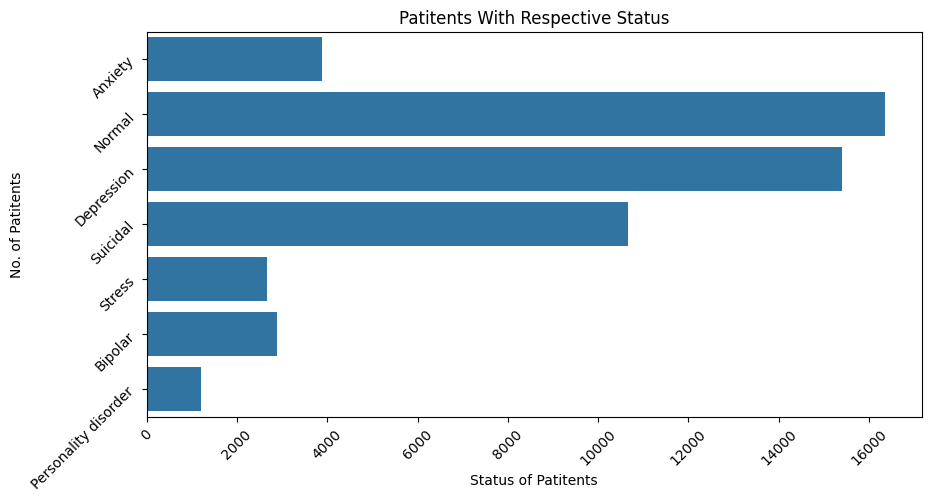

In [ ]:
mp.figure(figsize=(10,5))
sn.countplot(df['status'])
mp.xlabel("Status of Patitents")
mp.ylabel("No. of Patitents")
mp.title("Patitents With Respective Status")
mp.xticks(rotation=45)
mp.yticks(rotation=45)
mp.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53047 entries, 0 to 53046
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52681 non-null  object
 1   status     53042 non-null  object
dtypes: object(2)
memory usage: 829.0+ KB


In [ ]:
df.shape


(53047, 2)

In [ ]:
df.dropna(inplace=True)


In [ ]:
df.shape


(52680, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52680 entries, 0 to 53046
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52680 non-null  object
 1   status     52680 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


# **Resampling and Preprocessing**

In [ ]:
max_count=df['status'].value_counts().max()
max_count


16343

In [ ]:
def resmpl(df):
    max_count = df['status'].value_counts().max()

    df_resampled = pd.DataFrame()

    for status in df['status'].unique():
        df_class = df[df['status'] == status]
        if len(df_class) < max_count:
            df_class_resampled = resample(df_class,
                                          replace=True,
                                          n_samples=max_count,
                                          random_state=42)
            df_resampled = pd.concat([df_resampled, df_class_resampled])
        else:
            df_resampled = pd.concat([df_resampled, df_class])

    return df_resampled


df = resmpl(df)

In [ ]:
df.sample(5)


,statement,status
12789,i got my period yesterday night and i have not...,Depression
49715,Feeling of dread and frustration related to wo...,Bipolar
378,3 days anxious tremor,Anxiety
51465,"Are you a misanthrope? Just wondering, because...",Personality disorder
808,Amigos whats up?,Normal


In [ ]:
df.status.value_counts()


,count
status,
Anxiety,16343
Normal,16343
Depression,16343
Suicidal,16343
Stress,16343
Bipolar,16343
Personality disorder,16343


In [ ]:
df.shape


(114401, 2)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 114401 entries, 52353 to 51089
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   statement  114401 non-null  object
 1   status     114401 non-null  object
dtypes: object(2)
memory usage: 2.6+ MB


In [ ]:
df.isna().sum()


,0
statement,0
status,0


In [ ]:
df.duplicated().sum()


70889

In [ ]:
pt=PorterStemmer()
def preprocessing(x):
    l=[]

    text=r.sub('[^a-zA-Z0-9\s]','',x.lower())
    for i in text.split():
        l.append(pt.stem(i.lower()))


    return " ".join(l)

In [ ]:
df.head(5)

,statement,status
52353,Why must I find something wrong in my relation...,Anxiety
52701,water slide this is going to sound so stupid l...,Anxiety
34043,"Insomnia Last month, I suddenly developed the ...",Anxiety
34477,Tired of wasting my money and time I know noth...,Anxiety
34313,Head nodding tic - will it cause long term dam...,Anxiety


In [ ]:
df['statement']=df['statement'].apply(preprocessing)


In [ ]:
df.head(5)

,statement,status
52353,whi must i find someth wrong in my relationshi...,Anxiety
52701,water slide thi is go to sound so stupid lol b...,Anxiety
34043,insomnia last month i suddenli develop the wor...,Anxiety
34477,tire of wast my money and time i know noth is ...,Anxiety
34313,head nod tic will it cau long term damag hey a...,Anxiety


# **Splitting and Vectorization**

In [ ]:
x=df['statement']
y=df['status']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)


In [ ]:
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)


(91520,) (91520,) (22881,) (22881,)


In [ ]:
print(x_train)

49873    my best friend chang after he start date it hu...
12706    i know i am not ok yet i cannot help but wonde...
49912    about to be out of med im not veri smart and i...
13319    i am so suicid and depress i do not have anyon...
45523    troubl breath i have bipolar ii and it gotten ...
                               ...                        
48494    yin yoga is a wonder way to regul the nervou s...
51788    is it onli me ive been diagnos have bpd border...
51100    how mani friend do you have view pollhttpswwwr...
35617    blood in post nasal drip when i wake up in the...
484      im small i prais myself other peopl are discou...
Name: statement, Length: 91520, dtype: object


In [ ]:
vec=TfidfVectorizer()
x_train_tfidf=vec.fit_transform(x_train)
x_test_tfidf=vec.transform(x_test)

In [ ]:
print(x_train_tfidf.shape,x_test_tfidf.shape)


(91520, 50030) (22881, 50030)


In [ ]:
print(x_train_tfidf)


  (0, 30050)	0.03137813444214012
  (0, 6648)	0.08325657459100061
  (0, 17660)	0.06294268041345685
  (0, 8976)	0.08236681809841657
  (0, 2974)	0.1277446854358316
  (0, 20188)	0.4869751365192369
  (0, 41503)	0.059620869320985155
  (0, 11644)	0.10330748210173785
  (0, 23782)	0.06111633448503917
  (0, 22119)	0.08066099662871919
  (0, 44677)	0.054192262820119505
  (0, 38836)	0.3183883562423046
  (0, 46729)	0.2014230257188989
  (0, 31279)	0.03876442300577265
  (0, 43607)	0.08834766613348013
  (0, 35243)	0.16194171955897266
  (0, 4479)	0.07253812716717915
  (0, 47514)	0.04463843294871508
  (0, 45221)	0.12723992335666778
  (0, 4021)	0.11288624055253645
  (0, 8397)	0.09133440978812701
  (0, 5791)	0.06279047956084978
  (0, 49596)	0.10483628118268132
  (0, 40535)	0.038682062806273225
  (0, 8340)	0.08122582502511504
  :	:
  (91518, 30338)	0.11388491996153466
  (91518, 9994)	0.09530489338367155
  (91518, 40021)	0.11777450394208
  (91518, 35926)	0.13939805880056066
  (91518, 34005)	0.244969420859020

In [ ]:
print(x_test_tfidf)


  (0, 2419)	0.05037263825725596
  (0, 3713)	0.07325011569974033
  (0, 3728)	0.04956890360571895
  (0, 4021)	0.15689880074144635
  (0, 4803)	0.11739683370593369
  (0, 5292)	0.05223501737576954
  (0, 6302)	0.054407633311640266
  (0, 6410)	0.18107358698775441
  (0, 6690)	0.07642649512539151
  (0, 8157)	0.07811894046425893
  (0, 8340)	0.09031559186166033
  (0, 10495)	0.14762386068449931
  (0, 10552)	0.1148683486670823
  (0, 13565)	0.11692027198513037
  (0, 14246)	0.10918134759433772
  (0, 14247)	0.1747582587316894
  (0, 14307)	0.128470906141762
  (0, 15489)	0.05769244283843541
  (0, 16013)	0.17410533337281933
  (0, 18460)	0.048876521573741886
  (0, 19970)	0.08144628789266325
  (0, 20113)	0.03790002934788915
  (0, 21443)	0.05628799051446537
  (0, 22445)	0.1089528358603487
  (0, 22623)	0.09702181359601629
  :	:
  (22880, 6648)	0.15114842788277028
  (22880, 6690)	0.1247844410547799
  (22880, 7355)	0.20749170617965046
  (22880, 7366)	0.393086889909251
  (22880, 8098)	0.36735726805680596
  (228

# **Model Training and Evaluation**

In [ ]:
rf=RandomForestClassifier()
rf.fit(x_train_tfidf,y_train)

RandomForestClassifier()

Confusion Matrix:
 [[3298    2   11   17    0    1    2]
 [   0 3174    9    2    0    0    8]
 [  22   10 2830  119    0    4  327]
 [  15    4   78 3113    0   36   14]
 [   0    0    0    0 3186    0    0]
 [   1    0    9    1    0 3248    0]
 [   1    0  257  114    0    1 2967]]


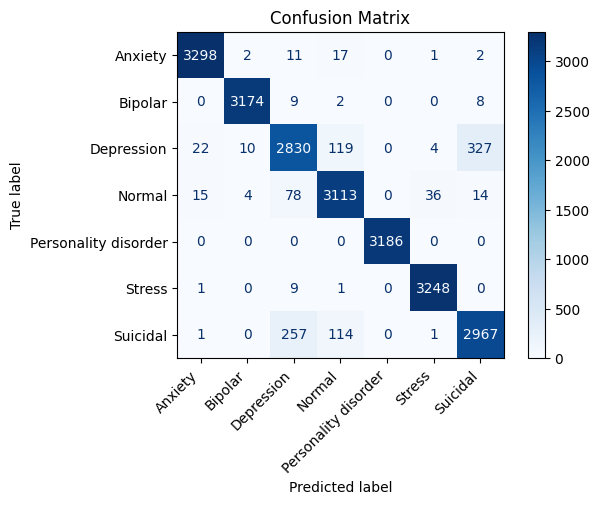

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict the labels for the test dataset
y_pred = rf.predict(x_test_tfidf)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:\n", cm)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)

# Adjust label spacing
plt.xticks(rotation=45, ha="right", fontsize=10)  # Rotate x-axis labels
plt.yticks(fontsize=10)  # Adjust y-axis label size
plt.gcf().subplots_adjust(bottom=0.2)  # Increase space at the bottom for labels
plt.title("Confusion Matrix")
plt.show()


In [ ]:
ypred=rf.predict(x_test_tfidf)
ytr_pred=rf.predict(x_train_tfidf)
print("Test accuracy: ",accuracy_score(y_test,ypred))
print("Train accuracy: ",accuracy_score(y_train,ytr_pred))
print("Precision Test accuracy: ",precision_score(y_test,ypred,average='weighted'))
print("Precision Train accuracy: ",precision_score(y_train,ytr_pred,average='weighted'))

Test accuracy:  0.9523622219308596
Train accuracy:  0.9996722027972028
Precision Test accuracy:  0.952048319273114
Precision Train accuracy:  0.9996726281217566


In [ ]:
adb=AdaBoostClassifier()
adb.fit(x_train_tfidf,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier()

Confusion Matrix:
 [[2299  148  115  198  154  391   26]
 [ 140 2252  136  147  204  269   45]
 [  71   82 1834  316   74  132  803]
 [  17   14   48 2818   27  175  161]
 [ 138  131  148  229 2097  389   54]
 [ 355   98  188  332  291 1876  119]
 [  11   15  839  305   19   59 2092]]


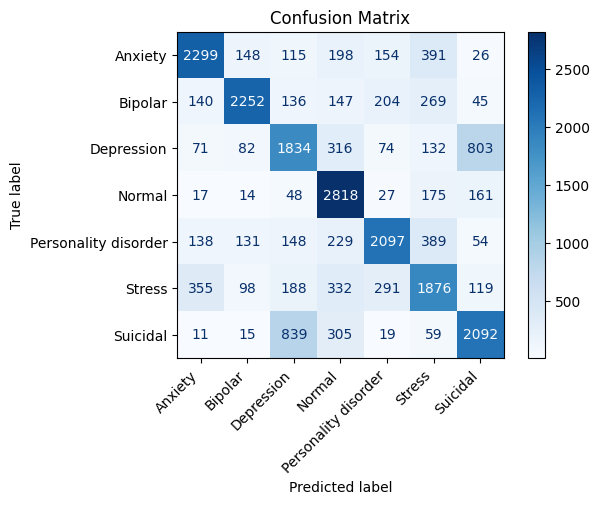

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict the labels for the test dataset
y_pred = adb.predict(x_test_tfidf)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:\n", cm)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)

# Adjust label spacing
plt.xticks(rotation=45, ha="right", fontsize=10)  # Rotate x-axis labels
plt.yticks(fontsize=10)  # Adjust y-axis label size
plt.gcf().subplots_adjust(bottom=0.2)  # Increase space at the bottom for labels
plt.title("Confusion Matrix")
plt.show()

In [ ]:
ypred=adb.predict(x_test_tfidf)
ytr_pred=adb.predict(x_train_tfidf)
print("Test accuracy: ",accuracy_score(y_test,ypred))
print("Train accuracy: ",accuracy_score(y_train,ytr_pred))
print("Precision Test accuracy: ",precision_score(y_test,ypred,average='weighted'))
print("Precision Train accuracy: ",precision_score(y_train,ytr_pred,average='weighted'))

Test accuracy:  0.667278528036362
Train accuracy:  0.6683347902097903
Precision Test accuracy:  0.6733818981397852
Precision Train accuracy:  0.6740908767276627


In [ ]:
ext=ExtraTreesClassifier()
ext.fit(x_train_tfidf,y_train)

ExtraTreesClassifier()

Confusion Matrix:
 [[3288    2   16   22    0    1    2]
 [   0 3174   12    7    0    0    0]
 [  12    5 2847  162    0    1  285]
 [  10    2   91 3135    0    6   16]
 [   0    0    0    0 3186    0    0]
 [   1    0   10    1    0 3246    1]
 [   1    0  328  124    0    1 2886]]


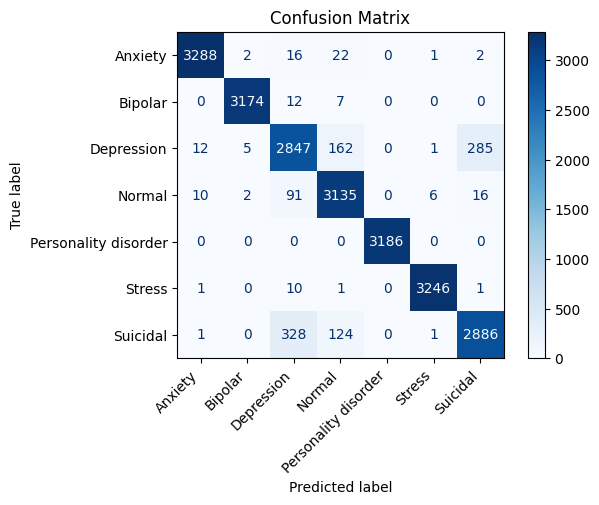

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict the labels for the test dataset
y_pred = ext.predict(x_test_tfidf)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:\n", cm)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)

# Adjust label spacing
plt.xticks(rotation=45, ha="right", fontsize=10)  # Rotate x-axis labels
plt.yticks(fontsize=10)  # Adjust y-axis label size
plt.gcf().subplots_adjust(bottom=0.2)  # Increase space at the bottom for labels
plt.title("Confusion Matrix")
plt.show()

In [ ]:
ypred=ext.predict(x_test_tfidf)
ytr_pred=ext.predict(x_train_tfidf)
print("Test accuracy: ",accuracy_score(y_test,ypred))
print("Train accuracy: ",accuracy_score(y_train,ytr_pred))
print("Precision Test accuracy: ",precision_score(y_test,ypred,average='weighted'))
print("Precision Train accuracy: ",precision_score(y_train,ytr_pred,average='weighted'))

Test accuracy:  0.9510947948079193
Train accuracy:  0.9996722027972028
Precision Test accuracy:  0.9511783225689249
Precision Train accuracy:  0.9996726281217566


In [ ]:
lr=LogisticRegression()
lr.fit(x_train_tfidf,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Confusion Matrix:
 [[3083   36   27   45   39   89   12]
 [  41 2978   43   32   44   41   14]
 [  83   77 2176  128   66   99  683]
 [  41   16   43 2967   20  128   45]
 [   4    2    0    3 3170    7    0]
 [ 130   25   55   31   39 2953   26]
 [  14    6  478  172   16   24 2630]]


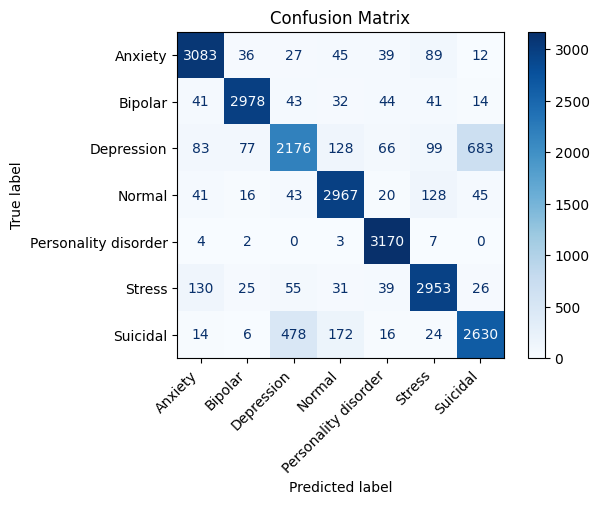

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict the labels for the test dataset
y_pred = lr.predict(x_test_tfidf)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:\n", cm)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)

# Adjust label spacing
plt.xticks(rotation=45, ha="right", fontsize=10)  # Rotate x-axis labels
plt.yticks(fontsize=10)  # Adjust y-axis label size
plt.gcf().subplots_adjust(bottom=0.2)  # Increase space at the bottom for labels
plt.title("Confusion Matrix")
plt.show()

In [ ]:
ypred=lr.predict(x_test_tfidf)
ytr_pred=lr.predict(x_train_tfidf)
print("Test accuracy: ",accuracy_score(y_test,ypred))
print("Train accuracy: ",accuracy_score(y_train,ytr_pred))
print("Precision Test accuracy: ",precision_score(y_test,ypred,average='weighted'))
print("Precision Train accuracy: ",precision_score(y_train,ytr_pred,average='weighted'))

Test accuracy:  0.8722083825007648
Train accuracy:  0.9010817307692308
Precision Test accuracy:  0.8697918447794732
Precision Train accuracy:  0.8997068161688948


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to evaluate a model
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    }
    return metrics

# Evaluate all the models
rf_metrics = evaluate_model(rf, x_test_tfidf, y_test)
adb_metrics = evaluate_model(adb, x_test_tfidf, y_test)
ext_metrics = evaluate_model(ext, x_test_tfidf, y_test)
lr_metrics = evaluate_model(lr, x_test_tfidf, y_test)

# Combine results for comparison
comparison_df = pd.DataFrame({
    "Random Forest": rf_metrics,
    "AdaBoost": adb_metrics,
    "Extra Trees": ext_metrics,
    "Logistic Regression": lr_metrics
}).T  # Transpose for better readability

# Display results
print(comparison_df)

# Optionally save the results to a CSV file
comparison_df.to_csv("model_comparison.csv", index=True)


                     Accuracy  Precision    Recall  F1 Score
Random Forest        0.952362   0.952048  0.952362  0.952083
AdaBoost             0.666929   0.673226  0.666929  0.666709
Extra Trees          0.952187   0.952194  0.952187  0.952031
Logistic Regression  0.873607   0.871170  0.873607  0.871515


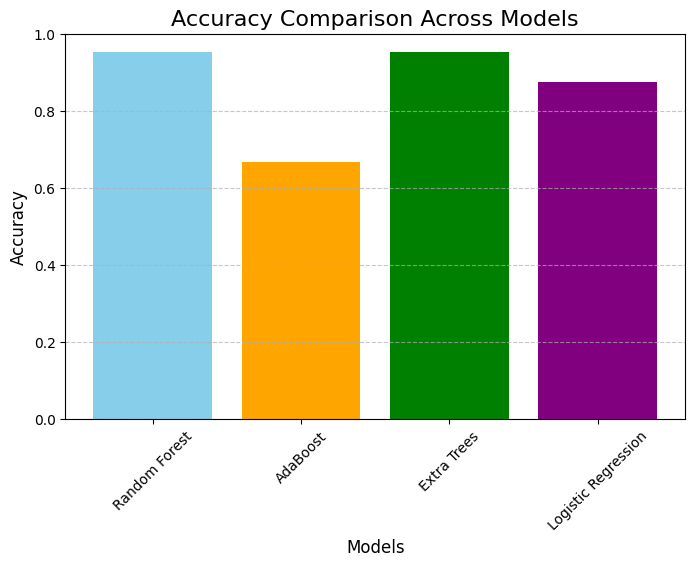

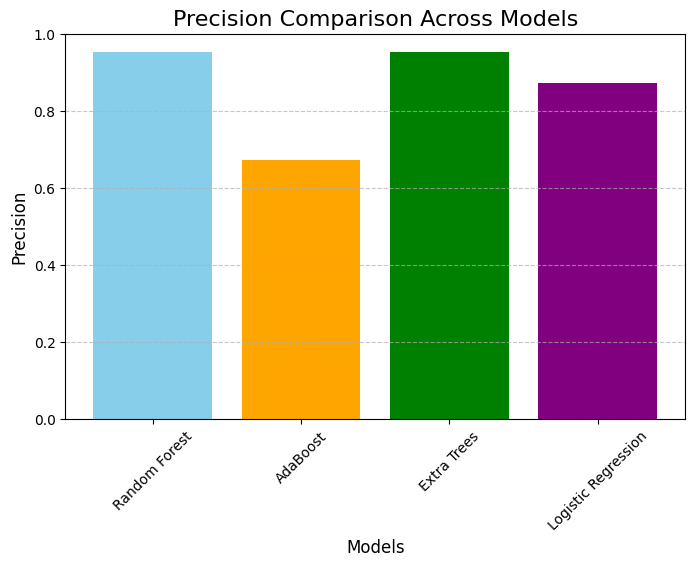

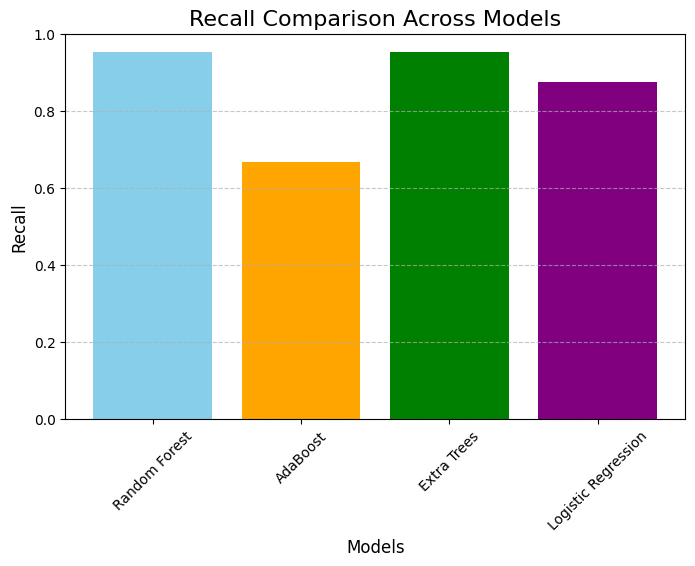

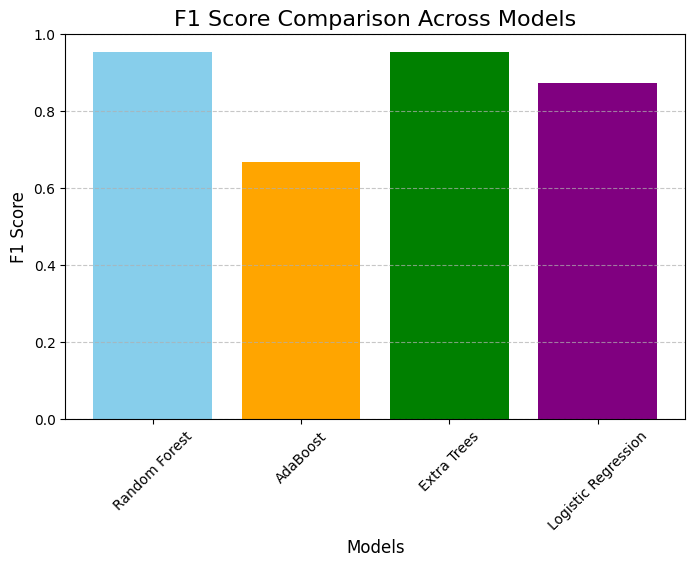

In [ ]:
import matplotlib.pyplot as plt

# Function to plot metrics
def plot_metrics(comparison_df, metric):
    plt.figure(figsize=(8, 5))
    models = comparison_df.index
    values = comparison_df[metric]

    # Create a bar plot
    plt.bar(models, values, color=['skyblue', 'orange', 'green', 'purple'])
    plt.title(f'{metric} Comparison Across Models', fontsize=16)
    plt.xlabel('Models', fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.xticks(rotation=45)
    plt.ylim(0, 1)  # Assuming metrics are normalized between 0 and 1
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Plot each metric
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
for metric in metrics_to_plot:
    plot_metrics(comparison_df, metric)


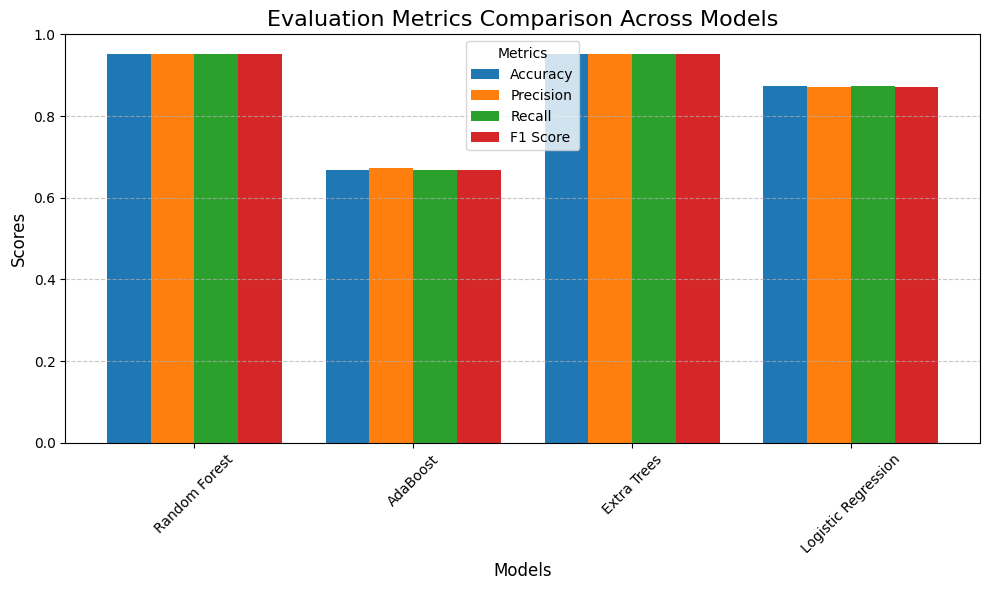

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function to plot all metrics in one plot
def plot_all_metrics(comparison_df):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    models = comparison_df.index
    n_metrics = len(metrics)

    # Bar width and x-axis positions
    bar_width = 0.2
    x_positions = np.arange(len(models))

    # Plot each metric as a group of bars
    plt.figure(figsize=(10, 6))
    for i, metric in enumerate(metrics):
        plt.bar(x_positions + i * bar_width, comparison_df[metric], bar_width, label=metric)

    # Add labels and title
    plt.title('Evaluation Metrics Comparison Across Models', fontsize=16)
    plt.xlabel('Models', fontsize=12)
    plt.ylabel('Scores', fontsize=12)
    plt.xticks(x_positions + bar_width * (n_metrics / 2 - 0.5), models, rotation=45)
    plt.ylim(0, 1)  # Assuming metrics are normalized between 0 and 1
    plt.legend(title='Metrics')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Call the function
plot_all_metrics(comparison_df)


In [ ]:
import numpy as np
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from time import time

# Define the models
models = {
    'Random Forest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Extra Trees': ExtraTreesClassifier(),
    'Logistic Regression': LogisticRegression()
}

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, average='weighted')
}

# Placeholder for results
results = []

# Train and evaluate each model using K-fold cross-validation
for name, model in models.items():
    start_time = time()  # Start the timer
    scores = cross_validate(model, x_train_tfidf, y_train, cv=2, scoring=scoring, return_train_score=False)
    end_time = time()  # End the timer

    # Compute the average of each metric across the folds
    accuracy = np.mean(scores['test_accuracy'])
    f1 = np.mean(scores['test_f1'])
    elapsed_time = end_time - start_time  # Time taken to run the model

    # Store the results in the list
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1-score': f1,
        'Time (s)': elapsed_time
    })

    print(f"{name} completed in {elapsed_time:.4f} seconds.")

# Display the results
import pandas as pd
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)


Random Forest completed in 495.0419 seconds.


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost completed in 243.3881 seconds.
Extra Trees completed in 663.7543 seconds.


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression completed in 48.6201 seconds.
                 Model  Accuracy  F1-score    Time (s)
0        Random Forest  0.909397  0.908442  495.041879
2          Extra Trees  0.907354  0.907246  663.754344
3  Logistic Regression  0.850896  0.848945   48.620118
1             AdaBoost  0.661025  0.660545  243.388109


In [ ]:
# Define the models
models = {
    'Random Forest': rf,
    'AdaBoost': adb,
    'Extra Trees': ext,
    'Logistic Regression': lr
}

In [ ]:
import pandas as pd

# Assuming you have these variables
# x_test_tfidf: Transformed test features
# y_test: Actual labels for the test set
# statements: Original test statements (before transformation)

test_index = y_test.index

# Filter the statements list using the test set indices
statements = [statements[i] for i in test_index]


# Create a dictionary to store DataFrames for each model
model_dfs = {}

# Iterate over each model
for name, model in models.items():
    # Get predicted statuses
    y_pred = model.predict(x_test_tfidf)

    # Create a DataFrame with the required columns
    df = pd.DataFrame({
        'Statements': statements,
        'Actual Status': y_test,
        'Predicted Status': y_pred
    })

    # Store the DataFrame in the dictionary
    model_dfs[name] = df

    # Save to CSV (optional)
    df.to_csv(f"{name}_predictions.csv", index=False)
    print(f"DataFrame for {name} created and saved as {name}_predictions.csv.")

# Access individual DataFrames like this:
# model_dfs['Random Forest']


DataFrame for Random Forest created and saved as Random Forest_predictions.csv.
DataFrame for AdaBoost created and saved as AdaBoost_predictions.csv.
DataFrame for Extra Trees created and saved as Extra Trees_predictions.csv.
DataFrame for Logistic Regression created and saved as Logistic Regression_predictions.csv.


In [ ]:
model_dfs['Random Forest'].head(5)

,Statements,Actual Status,Predicted Status
51678,how should i stop obsess over songwrit so im i...,Personality disorder,Personality disorder
46243,i know thi may seem like a small thing but to ...,Bipolar,Bipolar
30147,a person i follow on instagram misunderstood m...,Normal,Depression
22312,thi is not antitherapi therapi can teach you a...,Depression,Depression
28764,am i stress thi year me and my famili and i ha...,Stress,Stress


In [ ]:
model_dfs['Extra Trees'].head(5)

,Statements,Actual Status,Predicted Status
51678,how should i stop obsess over songwrit so im i...,Personality disorder,Personality disorder
46243,i know thi may seem like a small thing but to ...,Bipolar,Bipolar
30147,a person i follow on instagram misunderstood m...,Normal,Depression
22312,thi is not antitherapi therapi can teach you a...,Depression,Depression
28764,am i stress thi year me and my famili and i ha...,Stress,Stress


In [ ]:
model_dfs['Logistic Regression'].head(5)

,Statements,Actual Status,Predicted Status
51678,how should i stop obsess over songwrit so im i...,Personality disorder,Personality disorder
46243,i know thi may seem like a small thing but to ...,Bipolar,Bipolar
30147,a person i follow on instagram misunderstood m...,Normal,Personality disorder
22312,thi is not antitherapi therapi can teach you a...,Depression,Depression
28764,am i stress thi year me and my famili and i ha...,Stress,Anxiety


In [ ]:
model_dfs['AdaBoost'].head(5)

,Statements,Actual Status,Predicted Status
51678,how should i stop obsess over songwrit so im i...,Personality disorder,Personality disorder
46243,i know thi may seem like a small thing but to ...,Bipolar,Bipolar
30147,a person i follow on instagram misunderstood m...,Normal,Stress
22312,thi is not antitherapi therapi can teach you a...,Depression,Suicidal
28764,am i stress thi year me and my famili and i ha...,Stress,Stress


In [ ]:
# Compress model.pkl
with gzip.open('model.pkl.gz', 'wb') as f:
    pickle.dump(rf, f)

In [ ]:
# Compress vectorizer.pkl
with gzip.open('vectorizer.pkl.gz', 'wb') as f:
    pickle.dump(vec, f)

# **Bert Model**

Dataset Preparation

In [ ]:
pip install transformers datasets torch scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 14.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

Data Reduction

In [ ]:
# Ran the first two sections of the code and upto the resampling part in the section 3 to get the balanced dataframe.

In [ ]:
df = df.dropna(subset=['status'])  # Remove rows with NaN in the 'status' column


In [ ]:
label_mapping = {
    "Stress": 0,
    "Anxiety": 1,
    "Depression": 2,
    "Personality disorder": 3,
    "Bipolar": 4,
    "Suicidal": 5,
    "Normal": 6,
}

df['label'] = df['status'].map(label_mapping)

# Checking if any labels are still NaN after mapping
print(df['label'].isna().sum())


0


In [ ]:
print(df.head())

   Id                                          statement   status  label
0   0                                         oh my gosh  Anxiety      1
1   1  trouble sleeping, confused mind, restless hear...  Anxiety      1
2   2  All wrong, back off dear, forward doubt. Stay ...  Anxiety      1
3   3  I've shifted my focus to something else but I'...  Anxiety      1
4   4  I'm restless and restless, it's been a month n...  Anxiety      1


In [ ]:
print(df['status'].unique())  # Should show the unique strings in 'status'
print(df['label'].unique())   # Should show integers 0 to 6


['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']
[1 6 2 5 0 4 3]


In [ ]:
# Split the dataset into training and testing sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['statement'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42
)
# Ensure all elements in train_texts and val_texts are strings
train_texts = [str(text) for text in train_texts] # Convert any non-string elements to strings
val_texts = [str(text) for text in val_texts]    # Convert any non-string elements to strings

# Ensure all labels are integers or NaN, then convert NaN to -1
# train_labels and val_labels should already be numerical since they were mapped using label_mapping
train_labels = pd.Series(train_labels).fillna(-1).astype(int).tolist()
val_labels = pd.Series(val_labels).fillna(-1).astype(int).tolist()

# handling NaN values
train_data = Dataset.from_dict({"text": train_texts, "label": train_labels})
val_data = Dataset.from_dict({"text": val_texts, "label": val_labels})

In [ ]:
print(train_data)

Dataset({
    features: ['text', 'label'],
    num_rows: 42433
})


In [ ]:
# Convert to Hugging Face Dataset format

# Ensure all elements in train_texts and val_texts are strings
train_texts = [str(text) for text in train_texts] # Convert any non-string elements to strings
val_texts = [str(text) for text in val_texts]    # Convert any non-string elements to strings

# Ensure all labels are integers or NaN, then convert NaN to -1
train_labels = pd.Series(train_labels).fillna(-1).astype(int).tolist()
val_labels = pd.Series(val_labels).fillna(-1).astype(int).tolist()

# handling NaN values
train_data = Dataset.from_dict({"text": train_texts, "label": [int(x) if not pd.isnull(x) else -1 for x in train_labels]}) # Convert nan to -1 or any other suitable integer.
val_data = Dataset.from_dict({"text": val_texts, "label": [int(x) if not pd.isnull(x) else -1 for x in val_labels]}) # Convert nan to -1 or any other suitable integer.

Tokenization

In [ ]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: fineGrained).
The token `SentimentAnalysis` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `

In [ ]:
# Load the tokenizer
MODEL_NAME = "bert-base-uncased"  # Change to "roberta-base" if using RoBERTa
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# Tokenize the data
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

In [ ]:
train_data = train_data.map(preprocess_function, batched=True)
val_data = val_data.map(preprocess_function, batched=True)

Map:   0%|          | 0/42433 [00:00<?, ? examples/s]

Map:   0%|          | 0/10609 [00:00<?, ? examples/s]

In [ ]:
# Remove the text column (not needed after tokenization)
train_data = train_data.remove_columns(["text"])
val_data = val_data.remove_columns(["text"])

In [ ]:
# Set the dataset format for PyTorch
train_data.set_format("torch")
val_data.set_format("torch")

In [ ]:
print(train_data)

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 42433
})


Model initialization

In [ ]:
# Load the pre-trained BERT or RoBERTa model
num_labels = len(label_mapping)  # Number of unique classes
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Defining evaluation metrics

In [ ]:
# Define metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}


Training

In [ ]:
# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",           # Directory to save results
    evaluation_strategy="epoch",     # Evaluate every epoch
    save_strategy="epoch",           # Save the model every epoch
    per_device_train_batch_size=16,  # Batch size for training
    per_device_eval_batch_size=16,   # Batch size for evaluation
    num_train_epochs=4,              # Number of epochs
    weight_decay=0.01,               # Weight decay
    logging_dir="./logs",            # Directory for logs
    logging_steps=10,
    load_best_model_at_end=True,     # Load the best model at the end
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-22-2444e55595d2>:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# Before training, examine and fix labels in your datasets
def fix_labels(dataset):
    # Get labels from the dataset
    labels = dataset['label']

    # Identify invalid labels (e.g., -1)
    invalid_indices = np.where(labels == -1)[0]

    # Replace invalid labels with a valid label or remove the corresponding examples
    if invalid_indices.size > 0:
        # **Change**: Replace with a label within the model's expected range
        # Assuming your model has 'num_labels' classes, use a label between 0 and num_labels - 1
        # For example, if your model has 2 classes, replace -1 with 0 or 1

        # Get the number of labels from the model
        num_labels = model.config.num_labels

        # Replace -1 with a valid label (e.g., 0) within the range 0 to num_labels - 1
        labels[invalid_indices] = 1  # Or any other valid label within the range

        # print(f"Fixed {len(invalid_indices)} invalid labels in dataset.")

    # Remove examples with invalid labels that could not be fixed
    # (If you choose to remove instead of replacing)
    # valid_indices = np.where(labels != -1)[0]
    # dataset = dataset.select(valid_indices)


    # Update the dataset with fixed labels
    dataset = dataset.remove_columns(['label'])

    # Define the features of the new column, including existing columns
    from datasets import Features, Value
    features = Features({
        'input_ids': dataset.features['input_ids'],
        'token_type_ids': dataset.features['token_type_ids'],
        'attention_mask': dataset.features['attention_mask'],
        'label': Value('int64')  # Explicitly define the 'label' feature as int64
    })

    # Convert labels to a standard Python list before adding
    dataset = dataset.add_column('label', labels.tolist())
    # datasets infers the type automatically
    # The features dictionary is used for casting to the desired type
    dataset = dataset.cast(features)  # Cast the dataset to the defined features

    return dataset

train_data = fix_labels(train_data)
val_data = fix_labels(val_data)

Casting the dataset:   0%|          | 0/42433 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/10609 [00:00<?, ? examples/s]

In [ ]:
# Train the model
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.432800,0.480428,0.805920,0.802884,0.813965,0.805920
2,0.441100,0.425500,0.830710,0.829782,0.830361,0.830710
3,0.341100,0.505904,0.829956,0.830128,0.832238,0.829956
4,0.059100,0.710693,0.830616,0.831370,0.832737,0.830616


TrainOutput(global_step=10612, training_loss=0.330341412307736, metrics={'train_runtime': 4125.4904, 'train_samples_per_second': 41.142, 'train_steps_per_second': 2.572, 'total_flos': 1.11650926238976e+16, 'train_loss': 0.330341412307736, 'epoch': 4.0})

Save and Load the model

In [ ]:
# Save the fine-tuned model
model.save_pretrained("./mental_health_model")
tokenizer.save_pretrained("./mental_health_model")

('./mental_health_model/tokenizer_config.json',
 './mental_health_model/special_tokens_map.json',
 './mental_health_model/vocab.txt',
 './mental_health_model/added_tokens.json',
 './mental_health_model/tokenizer.json')

In [ ]:
# Load the saved model for later use
from transformers import AutoTokenizer, AutoModelForSequenceClassification

loaded_tokenizer = AutoTokenizer.from_pretrained("./mental_health_model")
loaded_model = AutoModelForSequenceClassification.from_pretrained("./mental_health_model")

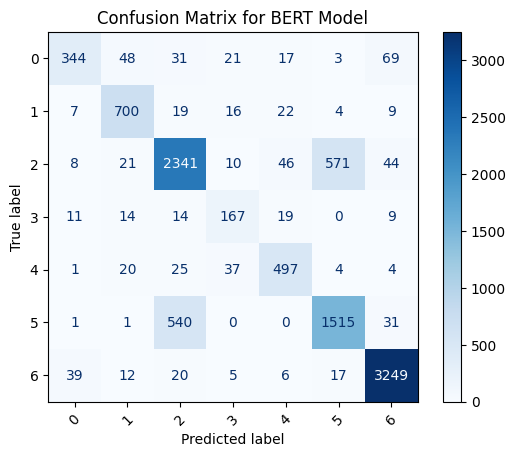

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Step 1: Get predictions from the trainer
predictions = trainer.predict(val_data)  # Use the validation dataset
y_true = np.array(val_data["label"])  # True labels (replace 'label' with the actual column name if different)
y_pred = np.argmax(predictions.predictions, axis=1)  # Predicted labels

# Step 2: Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Step 3: Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_mapping.values())  # Use your label mapping for display
disp.plot(cmap=plt.cm.Blues)

# Step 4: Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Step 5: Add title and show plot
plt.title("Confusion Matrix for BERT Model")
plt.show()

Prediction(Model Testing for roberta and bert model)

In [ ]:
def predict(text, model, tokenizer):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=128)
    outputs = model(**inputs)
    predictions = outputs.logits.argmax(-1).item()
    return predictions

In [ ]:
# Example usage
text_to_predict = "I am very happy"
predicted_label = predict(text_to_predict, loaded_model, loaded_tokenizer)
print(predicted_label)

6


In [ ]:
# Map the predicted label back to the status
inverse_label_mapping = {v: k for k, v in label_mapping.items()}
print("Predicted Status:", inverse_label_mapping[predicted_label])

Predicted Status: Normal


# **Roberta Model **

In [ ]:
pip install transformers datasets torch scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 18.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [ ]:
# Ran the first two sections of the code and upto the resampling part in the section 3 to get the balanced dataframe.

In [ ]:
df = df.dropna(subset=['status'])  # Remove rows with NaN in the 'status' column


In [ ]:
print(df.head())

                                               statement   status
52353  Why must I find something wrong in my relation...  Anxiety
52701  water slide this is going to sound so stupid l...  Anxiety
34043  Insomnia Last month, I suddenly developed the ...  Anxiety
34477  Tired of wasting my money and time I know noth...  Anxiety
34313  Head nodding tic - will it cause long term dam...  Anxiety


In [ ]:
label_mapping = {
    "Stress": 0,
    "Anxiety": 1,
    "Depression": 2,
    "Personality disorder": 3,
    "Bipolar": 4,
    "Suicidal": 5,
    "Normal": 6,
}

df['label'] = df['status'].map(label_mapping)

# Check if any labels are still NaN after mapping
print(df['label'].isna().sum())

0


In [ ]:
print(df['status'].unique())  # Should show the unique strings in 'status'
print(df['label'].unique())   # Should show integers 0 to 6

['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']
[1 6 2 5 0 4 3]


In [ ]:
print(df.head())

                                               statement   status  label
52353  Why must I find something wrong in my relation...  Anxiety      1
52701  water slide this is going to sound so stupid l...  Anxiety      1
34043  Insomnia Last month, I suddenly developed the ...  Anxiety      1
34477  Tired of wasting my money and time I know noth...  Anxiety      1
34313  Head nodding tic - will it cause long term dam...  Anxiety      1


In [ ]:
# Split the dataset into training and testing sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['statement'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42
)
# Ensure all elements in train_texts and val_texts are strings
train_texts = [str(text) for text in train_texts] # Convert any non-string elements to strings
val_texts = [str(text) for text in val_texts]    # Convert any non-string elements to strings

# Ensure all labels are integers or NaN, then convert NaN to -1
# train_labels and val_labels should already be numerical since they were mapped using label_mapping
train_labels = pd.Series(train_labels).fillna(-1).astype(int).tolist()
val_labels = pd.Series(val_labels).fillna(-1).astype(int).tolist()

# handling NaN values
train_data = Dataset.from_dict({"text": train_texts, "label": train_labels})
val_data = Dataset.from_dict({"text": val_texts, "label": val_labels})

In [ ]:
# Converting to Hugging Face Dataset format

# Ensure all elements in train_texts and val_texts are strings
train_texts = [str(text) for text in train_texts] # Convert any non-string elements to strings
val_texts = [str(text) for text in val_texts]    # Convert any non-string elements to strings

# Ensure all labels are integers or NaN, then convert NaN to -1
train_labels = pd.Series(train_labels).fillna(-1).astype(int).tolist()
val_labels = pd.Series(val_labels).fillna(-1).astype(int).tolist()

# handling NaN values
train_data = Dataset.from_dict({"text": train_texts, "label": [int(x) if not pd.isnull(x) else -1 for x in train_labels]}) # Convert nan to -1 or any other suitable integer.
val_data = Dataset.from_dict({"text": val_texts, "label": [int(x) if not pd.isnull(x) else -1 for x in val_labels]}) # Convert nan to -1 or any other suitable integer.

In [ ]:
for example in train_data:
    print(f"Text: {example['text']}")
    print(f"Label: {example['label']}")
    print("-" * 1)

Streaming output truncated to the last 5000 lines.
**Module 6:** http://www.cci.health.wa.gov.au/docs/Health%20Anxiety%20Module%206.pdf

**Module 7:**
http://www.cci.health.wa.gov.au/docs/ACF6428.pdf

**Module 8:**
http://www.cci.health.wa.gov.au/docs/Health%20Anxiety%20Module%208.pdf

**Module 9:**
http://www.cci.health.wa.gov.au/docs/Health%20Anxiety%20Module%209.pdf

&amp;nbsp;

**PARENT LINK:**
http://www.cci.health.wa.gov.au/resources/infopax.cfm?Info_ID=53


&amp;nbsp;

Good luck, friends. Hopefully these help.  If you happen to come across the missing modules, post them and I will add them to OP.

We will get through this

Label: 1
-
Text: If there are people who are really nice to me, I get confused myself, sometimes I get nervous, I get really dizzy thinking about how to repay the kindness and what if I can't repay the kindness :((((
Label: 1
-
Text: Feeling jealousy and not good enough when close friends start talking to someone else and direct most of their attention to them

In [ ]:
# Load the RoBERTa tokenizer
MODEL_NAME = "roberta-base"  # Change this if you want a different RoBERTa model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenize the data
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

train_data = train_data.map(preprocess_function, batched=True)
val_data = val_data.map(preprocess_function, batched=True)

# Remove the text column (not needed after tokenization)
train_data = train_data.remove_columns(["text"])
val_data = val_data.remove_columns(["text"])

# Set the dataset format for PyTorch
train_data.set_format("torch")
val_data.set_format("torch")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/42433 [00:00<?, ? examples/s]

Map:   0%|          | 0/10609 [00:00<?, ? examples/s]

In [ ]:
# Load the RoBERTa model
num_labels = len(label_mapping)  # Number of unique classes
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

# Define metrics for evaluation
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results_roberta",       # Directory to save results
    evaluation_strategy="epoch",         # Evaluate every epoch
    save_strategy="epoch",               # Save the model every epoch
    per_device_train_batch_size=16,      # Batch size for training
    per_device_eval_batch_size=16,       # Batch size for evaluation
    num_train_epochs=4,                  # Number of epochs
    weight_decay=0.01,                   # Weight decay
    logging_dir="./logs_roberta",        # Directory for logs
    logging_steps=10,
    load_best_model_at_end=True,         # Load the best model at the end
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-16-898c91fbbbb2>:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# Train the model
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.475000,0.496411,0.797436,0.795176,0.814503,0.797436
2,0.407700,0.432637,0.827034,0.826325,0.834268,0.827034
3,0.458900,0.432849,0.838345,0.838844,0.843632,0.838345
4,0.131200,0.506912,0.844660,0.844820,0.845351,0.844660


TrainOutput(global_step=10612, training_loss=0.3922211730812704, metrics={'train_runtime': 4185.8319, 'train_samples_per_second': 40.549, 'train_steps_per_second': 2.535, 'total_flos': 1.11650926238976e+16, 'train_loss': 0.3922211730812704, 'epoch': 4.0})

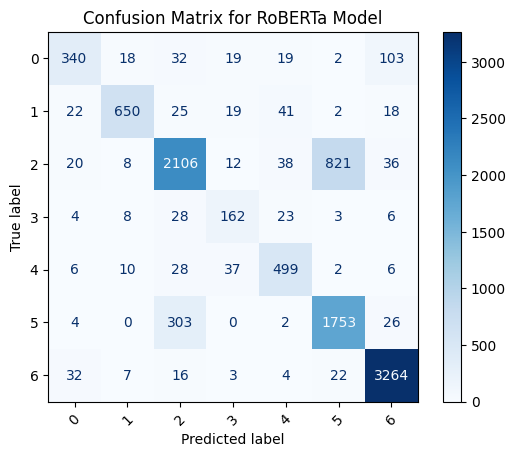

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Step 1: Get predictions from the trainer
predictions = trainer.predict(val_data)  # Use the validation dataset
y_true = np.array(val_data["label"])  # True labels (replace 'label' with the actual column name if different)
y_pred = np.argmax(predictions.predictions, axis=1)  # Predicted labels

# Step 2: Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Step 3: Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_mapping.values())  # Use your label mapping for display
disp.plot(cmap=plt.cm.Blues)

# Step 4: Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Step 5: Add title and show plot
plt.title("Confusion Matrix for RoBERTa Model")
plt.show()


In [ ]:
# Save the fine-tuned model
model.save_pretrained("./roberta_mental_health_model")
tokenizer.save_pretrained("./roberta_mental_health_model")

('./roberta_mental_health_model/tokenizer_config.json',
 './roberta_mental_health_model/special_tokens_map.json',
 './roberta_mental_health_model/vocab.json',
 './roberta_mental_health_model/merges.txt',
 './roberta_mental_health_model/added_tokens.json',
 './roberta_mental_health_model/tokenizer.json')

In [ ]:
# Load the saved model for later use
from transformers import AutoTokenizer, AutoModelForSequenceClassification

loaded_tokenizer = AutoTokenizer.from_pretrained("./roberta_mental_health_model")
loaded_model = AutoModelForSequenceClassification.from_pretrained("./roberta_mental_health_model")

In [ ]:
!pip install transformers datasets torch scikit-learn


In [ ]:
def predict(text, model, tokenizer):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=128)
    outputs = model(**inputs)
    predictions = outputs.logits.argmax(-1).item()
    return predictions

In [ ]:
# Example usage
text_to_predict = "I am very happy"
predicted_label = predict(text_to_predict, loaded_model, loaded_tokenizer)
print(predicted_label)

6


In [ ]:
# Map the predicted label back to the status
inverse_label_mapping = {v: k for k, v in label_mapping.items()}
print("Predicted Status:", inverse_label_mapping[predicted_label])

Predicted Status: Normal


# **Model Testing**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import gzip
import pickle
model_path='/content/drive/MyDrive/model.pkl.gz'
with gzip.open(model_path, 'rb') as file:
    model = pickle.load(file)

vector_path='/content/drive/MyDrive/vectorizer.pkl.gz'
with gzip.open(vector_path, 'rb') as file:
    vector = pickle.load(file)

In [ ]:
pt=PorterStemmer()
def preprocessing(x):
    l=[]

    text=r.sub('[^a-zA-Z0-9\s]','',x.lower())
    for i in text.split():
        l.append(pt.stem(i.lower()))




    return " ".join(l)

In [ ]:
def predi(x):
    text=preprocessing(x)
    vec=vector.transform([text])
    result=model.predict(vec)[0]

    return result

In [ ]:
text='Those extrovert specimens who take pride in publicly pointing out that I have been silent throughout the party deserve a special place in hell Congratulations on making this invaluable observation. You have successfully made it even more awkward for me now.'

In [ ]:
predi(text)

'Personality disorder'